In [ ]:
import pandas as pd
import numpy as np
from datetime import date, timedelta
from dateutil.relativedelta import relativedelta
import os
from tqdm import tqdm
from collections import Counter
import torch
from datetime import datetime
import jieba
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 資料載入


In [ ]:
merged_data = pd.read_csv('/content/drive/MyDrive/merged_data.csv', lineterminator='\n')

In [ ]:
merged_data.sort_values(by='post_time')

,post_time,all_content,stock_name_x,three_days_later,stock_name_y,stock_symbol,open,high,low,close,volume,date,單日漲跌幅(%),label
0,2022-03-01,#標的 3/1盤前功課 週末事件小結1. 烏俄戰爭似乎繼續延燒，短時間無法結束😔戰爭不會是股...,台積電,2022-03-04,台積電,2330,595.0,597.0,592.0,595.0,65235,2022-03-04,-0.011628,-1
24,2022-03-01,[新聞] 台積電將加入對俄羅斯制裁 經濟部長王美原文標題：斷俄晶片！台積電將加入對俄羅斯制裁...,台積電,2022-03-04,台積電,2330,595.0,597.0,592.0,595.0,65235,2022-03-04,-0.011628,-1
23,2022-03-01,[新聞] 竹科發生大規模壓降 晶圓廠部分機台跳電原文標題：竹科發生大規模壓降 晶圓廠部分機台...,台積電,2022-03-04,台積電,2330,595.0,597.0,592.0,595.0,65235,2022-03-04,-0.011628,-1
22,2022-03-01,[新聞] 被俄烏局勢莫名波及 台積電ADR連跌8天呈新聞來源：udn網址被俄烏局勢莫名波及 ...,台積電,2022-03-04,台積電,2330,595.0,597.0,592.0,595.0,65235,2022-03-04,-0.011628,-1
21,2022-03-01,[標的] 大盤 烏俄多1. 標的： 大盤 (例 2330.TW 台積電)2. 分類...,台積電,2022-03-04,台積電,2330,595.0,597.0,592.0,595.0,65235,2022-03-04,-0.011628,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10898,2024-02-23,《各報要聞》7利多上膛 台股攻萬九…快了【時報-台北電】輝達財報與財測優於市場預期，引領台股...,台積電,2024-02-26,台積電,2330,700.0,700.0,695.0,698.0,29976,2024-02-26,0.001435,0
10897,2024-02-23,《各報要聞》輝達上季財報猴賽雷！ 台鏈8雄迎財神【時報-台北電】「只有NV才能超越NV」！全...,台積電,2024-02-26,台積電,2330,700.0,700.0,695.0,698.0,29976,2024-02-26,0.001435,0
10896,2024-02-23,Nvidia股價大漲超過16%，週五台股有望維持創新高表現【財訊快報／魏聖峰】Nvidia獲...,台積電,2024-02-26,台積電,2330,700.0,700.0,695.0,698.0,29976,2024-02-26,0.001435,0
10904,2024-02-23,《基金》迎積情 半導體ETF新兵出擊【時報-台北電】台積電熊本一廠24日開幕，將帶動日本設備...,台積電,2024-02-26,台積電,2330,700.0,700.0,695.0,698.0,29976,2024-02-26,0.001435,0


## 回測 - 無特徵、關鍵字篩選 TF-IDF 向量模型

              precision    recall  f1-score   support

          -1       0.48      0.56      0.52       230
           0       0.42      0.38      0.40       196
           1       0.06      0.04      0.05        53

    accuracy                           0.43       479
   macro avg       0.32      0.33      0.32       479
weighted avg       0.41      0.43      0.41       479

Random Forest Classifier Accuracy: 0.4280


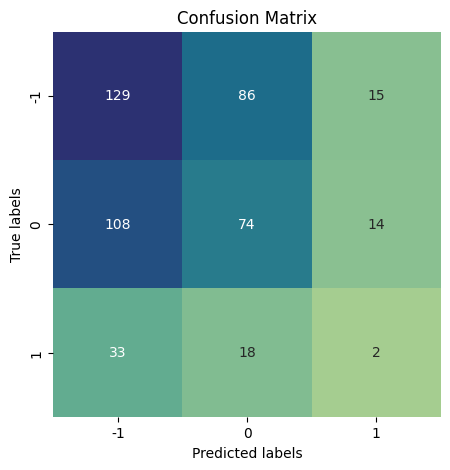

              precision    recall  f1-score   support

          -1       0.22      0.71      0.34       198
           0       0.36      0.26      0.30       316
           1       0.50      0.02      0.04       364

    accuracy                           0.26       878
   macro avg       0.36      0.33      0.23       878
weighted avg       0.39      0.26      0.20       878

Random Forest Classifier Accuracy: 0.2620


<Figure size 640x480 with 0 Axes>

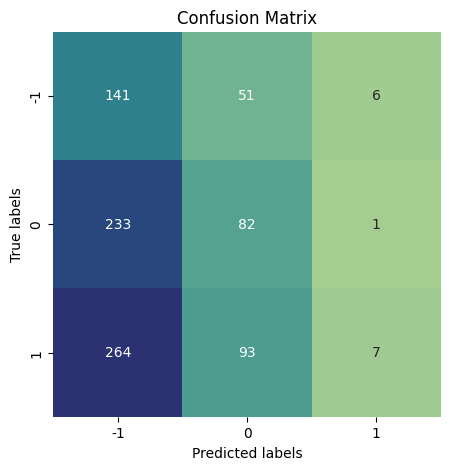

              precision    recall  f1-score   support

          -1       0.38      0.44      0.40       160
           0       0.50      0.31      0.38       233
           1       0.22      0.36      0.27       104

    accuracy                           0.36       497
   macro avg       0.37      0.37      0.35       497
weighted avg       0.40      0.36      0.37       497

Random Forest Classifier Accuracy: 0.3602


<Figure size 640x480 with 0 Axes>

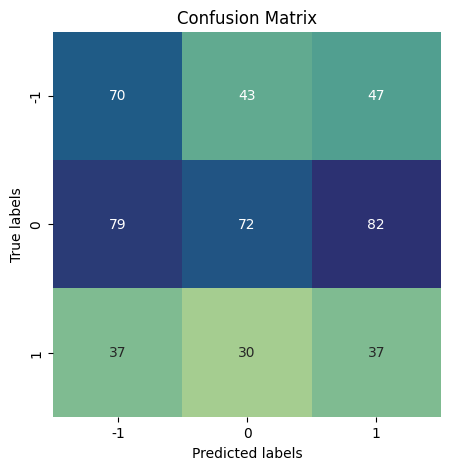

              precision    recall  f1-score   support

          -1       0.52      0.22      0.31       245
           0       0.39      0.72      0.50       180
           1       0.08      0.06      0.07        31

    accuracy                           0.40       456
   macro avg       0.33      0.33      0.29       456
weighted avg       0.44      0.40      0.37       456

Random Forest Classifier Accuracy: 0.4035


<Figure size 640x480 with 0 Axes>

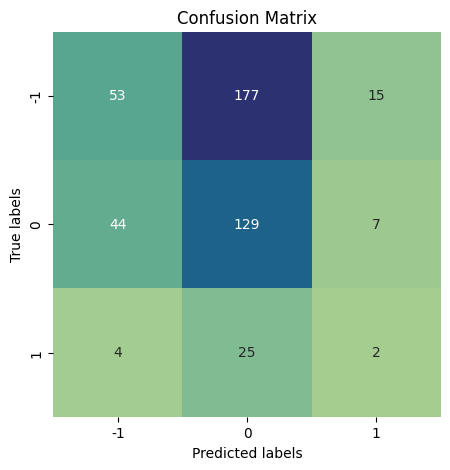

              precision    recall  f1-score   support

          -1       0.36      0.24      0.29       301
           0       0.22      0.64      0.33       161
           1       0.35      0.10      0.15       273

    accuracy                           0.27       735
   macro avg       0.31      0.32      0.26       735
weighted avg       0.33      0.27      0.25       735

Random Forest Classifier Accuracy: 0.2735


<Figure size 640x480 with 0 Axes>

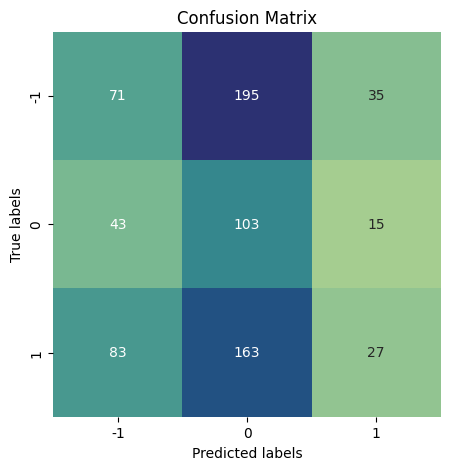

              precision    recall  f1-score   support

          -1       0.23      0.84      0.36       163
           0       0.46      0.14      0.21       383
           1       0.00      0.00      0.00       168

    accuracy                           0.26       714
   macro avg       0.23      0.33      0.19       714
weighted avg       0.30      0.26      0.19       714

Random Forest Classifier Accuracy: 0.2647


<Figure size 640x480 with 0 Axes>

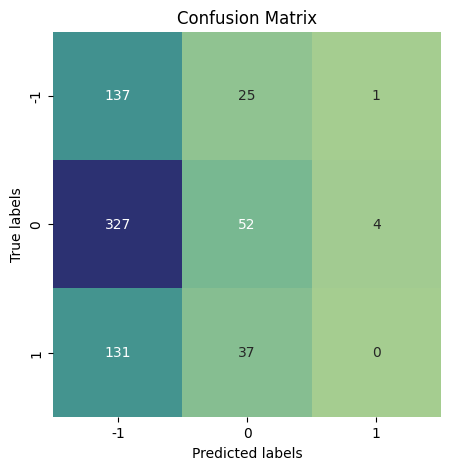

              precision    recall  f1-score   support

          -1       0.38      0.56      0.45       181
           0       0.50      0.47      0.48       262
           1       0.20      0.01      0.03        74

    accuracy                           0.43       517
   macro avg       0.36      0.35      0.32       517
weighted avg       0.41      0.43      0.41       517

Random Forest Classifier Accuracy: 0.4333


<Figure size 640x480 with 0 Axes>

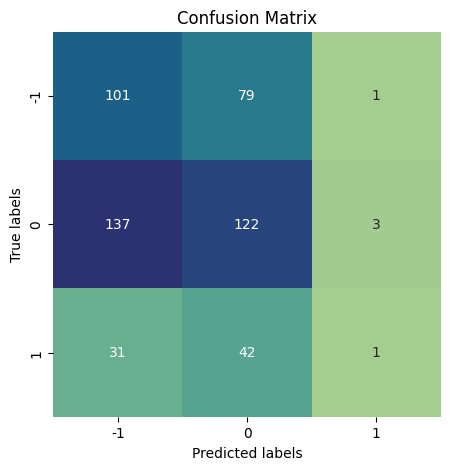

              precision    recall  f1-score   support

          -1       0.02      0.27      0.03        11
           0       0.23      0.47      0.31       114
           1       0.44      0.01      0.03       301

    accuracy                           0.14       426
   macro avg       0.23      0.25      0.12       426
weighted avg       0.38      0.14      0.10       426

Random Forest Classifier Accuracy: 0.1432


<Figure size 640x480 with 0 Axes>

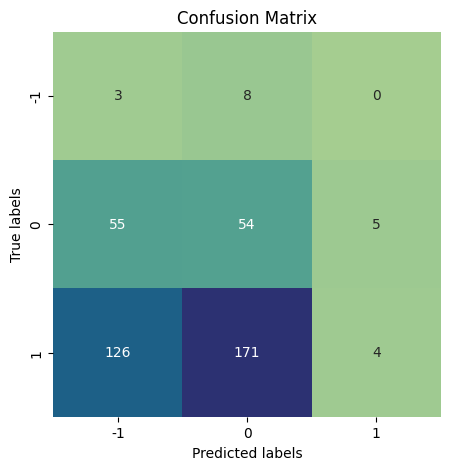

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00       118
           0       0.57      0.79      0.67       228
           1       0.10      0.15      0.12        54

    accuracy                           0.47       400
   macro avg       0.22      0.31      0.26       400
weighted avg       0.34      0.47      0.40       400

Random Forest Classifier Accuracy: 0.4725


<Figure size 640x480 with 0 Axes>

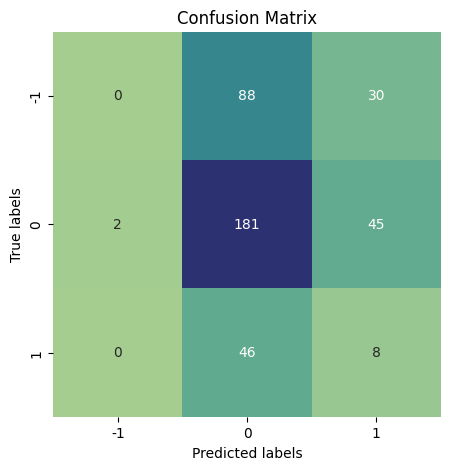

              precision    recall  f1-score   support

          -1       0.62      0.05      0.09       159
           0       0.58      0.93      0.71       231
           1       0.18      0.22      0.20        23

    accuracy                           0.55       413
   macro avg       0.46      0.40      0.33       413
weighted avg       0.57      0.55      0.45       413

Random Forest Classifier Accuracy: 0.5521


<Figure size 640x480 with 0 Axes>

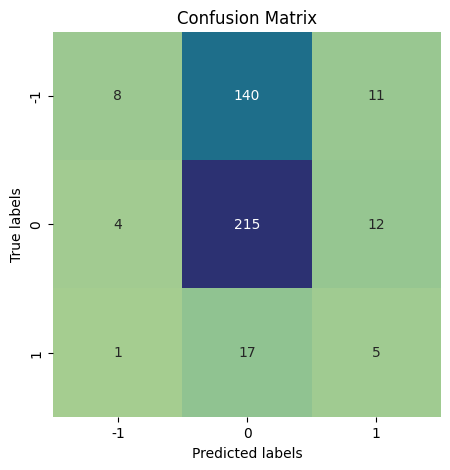

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00        77
           0       0.65      0.94      0.77       333
           1       0.06      0.01      0.02        96

    accuracy                           0.62       506
   macro avg       0.24      0.32      0.26       506
weighted avg       0.44      0.62      0.51       506

Random Forest Classifier Accuracy: 0.6186


<Figure size 640x480 with 0 Axes>

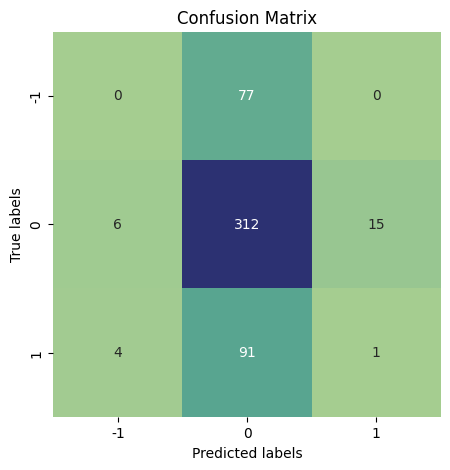

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00        30
           0       0.74      0.95      0.83       409
           1       0.00      0.00      0.00       114

    accuracy                           0.71       553
   macro avg       0.25      0.32      0.28       553
weighted avg       0.54      0.71      0.61       553

Random Forest Classifier Accuracy: 0.7052


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<Figure size 640x480 with 0 Axes>

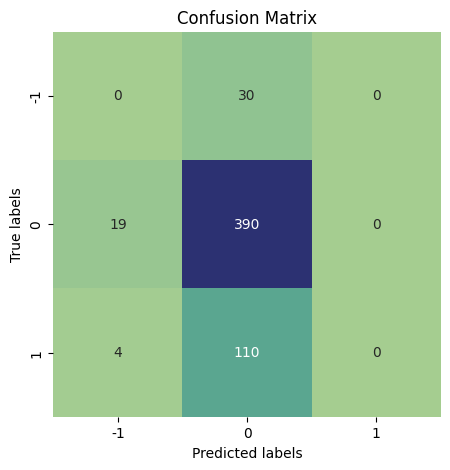

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00       109
           0       0.48      1.00      0.65       213
           1       0.00      0.00      0.00       123

    accuracy                           0.48       445
   macro avg       0.16      0.33      0.22       445
weighted avg       0.23      0.48      0.31       445

Random Forest Classifier Accuracy: 0.4787


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<Figure size 640x480 with 0 Axes>

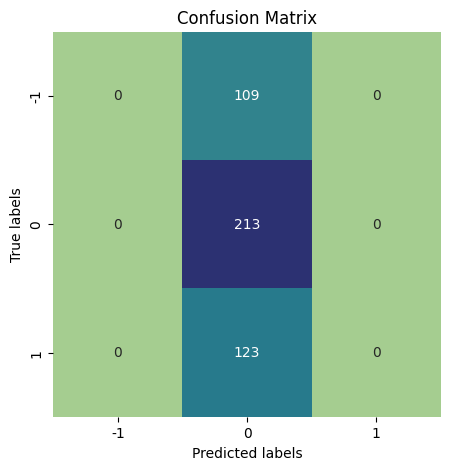

              precision    recall  f1-score   support

          -1       0.20      0.02      0.03        62
           0       0.73      0.99      0.84       449
           1       0.56      0.04      0.08       115

    accuracy                           0.72       626
   macro avg       0.49      0.35      0.32       626
weighted avg       0.64      0.72      0.62       626

Random Forest Classifier Accuracy: 0.7188


<Figure size 640x480 with 0 Axes>

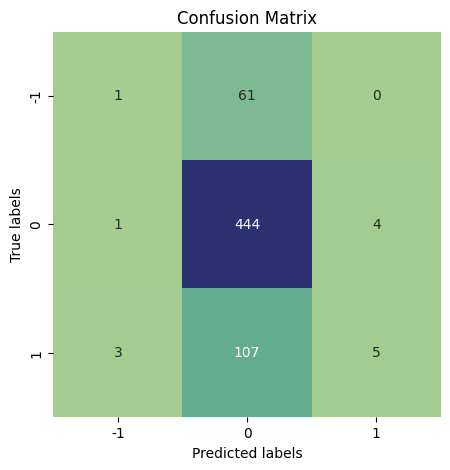

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00       104
           0       0.65      0.99      0.79       296
           1       0.33      0.02      0.04        52

    accuracy                           0.65       452
   macro avg       0.33      0.34      0.28       452
weighted avg       0.47      0.65      0.52       452

Random Forest Classifier Accuracy: 0.6527


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<Figure size 640x480 with 0 Axes>

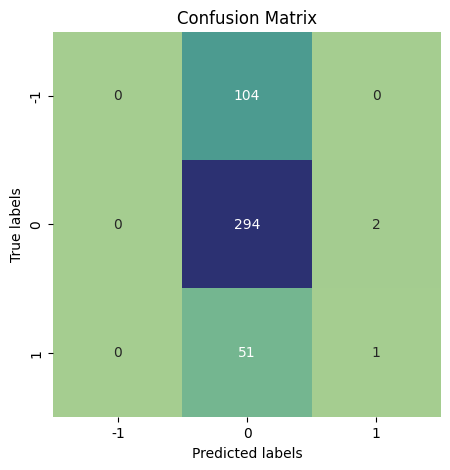

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00       144
           0       0.53      0.99      0.69       267
           1       0.33      0.01      0.02        94

    accuracy                           0.53       505
   macro avg       0.29      0.33      0.24       505
weighted avg       0.34      0.53      0.37       505

Random Forest Classifier Accuracy: 0.5267


<Figure size 640x480 with 0 Axes>

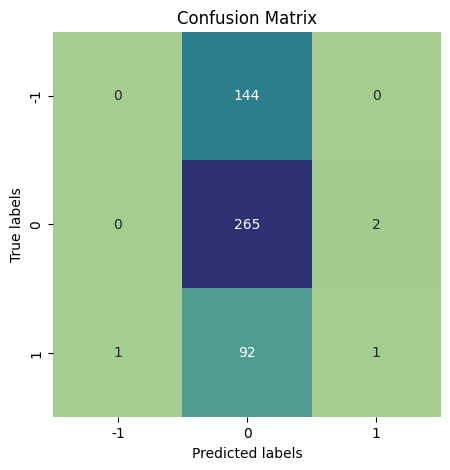

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00       197
           0       0.28      0.99      0.44       145
           1       0.00      0.00      0.00       169

    accuracy                           0.28       511
   macro avg       0.09      0.33      0.15       511
weighted avg       0.08      0.28      0.12       511

Random Forest Classifier Accuracy: 0.2818


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<Figure size 640x480 with 0 Axes>

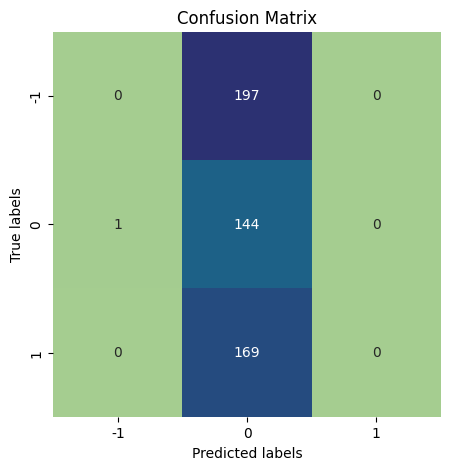

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00        16
           0       0.84      0.92      0.88       405
           1       0.00      0.00      0.00        64

    accuracy                           0.77       485
   macro avg       0.28      0.31      0.29       485
weighted avg       0.70      0.77      0.73       485

Random Forest Classifier Accuracy: 0.7691


<Figure size 640x480 with 0 Axes>

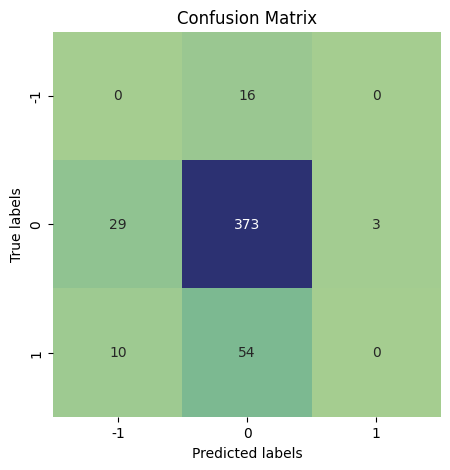

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00        27
           0       0.94      0.98      0.96       480
           1       0.00      0.00      0.00         5

    accuracy                           0.92       512
   macro avg       0.31      0.33      0.32       512
weighted avg       0.88      0.92      0.90       512

Random Forest Classifier Accuracy: 0.9219


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<Figure size 640x480 with 0 Axes>

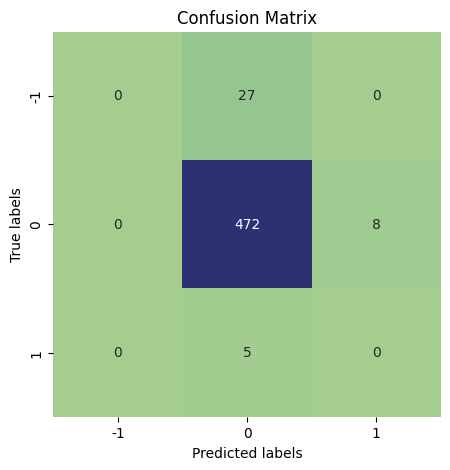

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00        24
           0       0.68      1.00      0.81       516
           1       0.00      0.00      0.00       214

    accuracy                           0.68       754
   macro avg       0.23      0.33      0.27       754
weighted avg       0.47      0.68      0.56       754

Random Forest Classifier Accuracy: 0.6830


<Figure size 640x480 with 0 Axes>

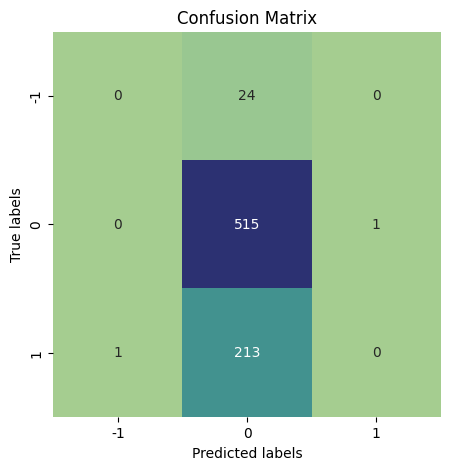

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00         9
           0       0.61      1.00      0.76       220
           1       0.00      0.00      0.00       133

    accuracy                           0.61       362
   macro avg       0.20      0.33      0.25       362
weighted avg       0.37      0.61      0.46       362

Random Forest Classifier Accuracy: 0.6077


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<Figure size 640x480 with 0 Axes>

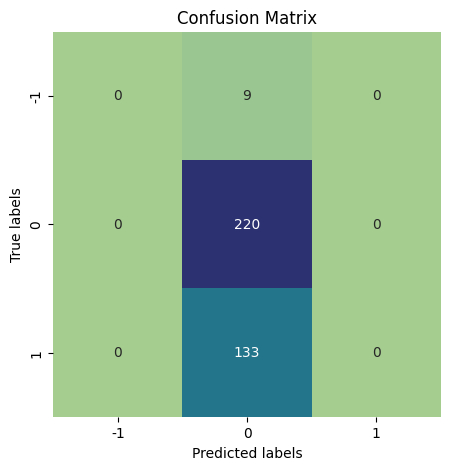

Average Accuracy:  0.5027149957947872


<Figure size 640x480 with 0 Axes>

In [ ]:
# 斷詞、特徵篩選、關鍵字
import monpa
import re
import emoji
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2

merged_data['post_time'] = pd.to_datetime(merged_data['post_time']).dt.date
start_date_train = datetime(2022, 3, 1).date()
end_date_test = datetime(2022, 6, 30).date()
accuracyL = []

# 前3個月用於訓練，後1個月用於測試
while end_date_test <= datetime(2024, 2, 28).date():
  end_date_train = (datetime.combine(start_date_train, datetime.min.time()) + relativedelta(months=3) - timedelta(days=1)).date()
  start_date_test = (datetime.combine(start_date_train, datetime.min.time()) + relativedelta(months=3)).date()

  x_train = merged_data[(merged_data['post_time'] >= start_date_train) & (merged_data['post_time'] <= end_date_train)]['all_content']
  y_train = merged_data[(merged_data['post_time'] >= start_date_train) & (merged_data['post_time'] <= end_date_train)]['label']

  x_test = merged_data[(merged_data['post_time'] >= start_date_test) & (merged_data['post_time'] <= end_date_test)]['all_content']
  y_test = merged_data[(merged_data['post_time'] >= start_date_test) & (merged_data['post_time'] <= end_date_test)]['label']

  # 使用 Monpa 斷詞
  def monpa_tokenizer(text):
      text = emoji.replace_emoji(text, replace='')
      tokens = monpa.cut(text)
      tokens_filtered = [token for token in tokens if not re.match(r'^[^\u4e00-\u9fffA-Za-z]+$', token)]
      return ' '.join(tokens_filtered)


  x_train_processed = x_train.apply(monpa_tokenizer)
  x_test_processed = x_test.apply(monpa_tokenizer)

  x_train_tfidf_matrix = tfidf_vectorizer_revised.fit_transform(x_train_processed)
  x_test_tfidf_matrix = tfidf_vectorizer_revised.transform(x_test_processed)

  y_test_pred_rf = rf_model.predict(x_test_tfidf_matrix)

  print(classification_report(y_test, y_test_pred_rf))
  accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
  print(f"Random Forest Classifier Accuracy: {accuracy_rf:.4f}")
  accuracyL.append(accuracy_rf)

  cm = confusion_matrix(y_test, y_test_pred_rf)
  class_labels = ['-1', '0','1']
  plt.figure(figsize=(5, 5))
  sns.heatmap(cm, annot=True, fmt='g', cmap="crest", cbar=False,
              xticklabels=class_labels, yticklabels=class_labels)
  plt.xlabel("Predicted labels")
  plt.ylabel("True labels")
  plt.title("Confusion Matrix")
  plt.show()
  save_path = "/content/drive/MyDrive/BDA_backtest/" + str(start_date_test).replace("-", "") + ".png"
  plt.savefig(save_path, bbox_inches="tight", pad_inches=0.1)

  # print(start_date_train, end_date_train)
  # print(start_date_test, end_date_test)
  # print()

  start_date_train = (datetime.combine(start_date_train, datetime.min.time()) + relativedelta(months=1)).date()
  end_date_test = (datetime.combine(end_date_test, datetime.min.time()) + relativedelta(months=1)).date()

print("Average Accuracy: ", sum(accuracyL)/len(accuracyL))

In [ ]:
print(accuracyL)
print(len(accuracyL))

[0.4279749478079332, 0.2619589977220957, 0.36016096579476864, 0.40350877192982454, 0.27346938775510204, 0.2647058823529412, 0.4332688588007737, 0.1431924882629108, 0.4725, 0.5520581113801453, 0.6185770750988142, 0.705244122965642, 0.4786516853932584, 0.7188498402555911, 0.6526548672566371, 0.5267326732673268, 0.28180039138943247, 0.7690721649484537, 0.921875, 0.6830238726790451, 0.6077348066298343]
21
